# Finding Redundant 1D Subspaces in LLM Activations

This notebook discovers **redundant 1-dimensional subspaces** in language model activations: directions where:
1. Activations have **large projections** (model actively uses this direction)
2. **Removing** this projection has **minimal impact** on output token distributions

In [1]:
import sys
import pathlib

# set pythonpath to the main module directory
module_dir = pathlib.Path("..").parent.resolve().parent
if str(module_dir) not in sys.path:
    sys.path.append(str(module_dir))

In [2]:
import torch
from src.utils.env import set_seed

set_seed(42)

torch.set_float32_matmul_precision("high")

In [ ]:
import json
import torch

meta_folder = "../logs/SILENT-DIRECTION/gemma-2b-it/hh-rlhf/model.layers.1/2026-02-17_20-24-16/metadata"

metadata_path = pathlib.Path(meta_folder) / "metadata.json"
direction_path = pathlib.Path(meta_folder) / "direction.pt"

metadata = json.load(open(metadata_path, "r"))
direction = torch.load(direction_path, weights_only=True)

In [4]:
from scripts.utils.load_dataset import load_dataset
from src.data import TableLoader

ds_train, ds_val, ds_test = load_dataset(metadata["dataset_name"])

dl_train = TableLoader(ds_train, batch_size=8, shuffle=True)
dl_val = TableLoader(ds_val, batch_size=8, shuffle=True)
dl_test = TableLoader(ds_test, batch_size=8, shuffle=True)

In [5]:
def is_chat_format(sample: object) -> bool:

    if isinstance(sample, str):
        return False

    if isinstance(sample, list) and all(isinstance(item, dict) for item in sample):
        return True

    raise ValueError("Unexpected format for 'prompt' field. Expected either a string or a list of dictionaries.")


batch = next(iter(dl_train))
sample_input = batch["prompt"][0]
is_chat = is_chat_format(sample_input)

In [6]:
import torch
from scripts.utils.load_model import load_model
from src.model import TargetedModel
from src.aliases import Conv

model, tokenizer = load_model(metadata["model_name"], dtype="bfloat16")
targeted_model = TargetedModel(model, tokenizer, is_chat=is_chat)
direction = direction.to(targeted_model.device)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [7]:
model

GemmaForCausalLM(
  (model): GemmaModel(
    (embed_tokens): Embedding(256000, 2048, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x GemmaDecoderLayer(
        (self_attn): GemmaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): GemmaMLP(
          (gate_proj): Linear(in_features=2048, out_features=16384, bias=False)
          (up_proj): Linear(in_features=2048, out_features=16384, bias=False)
          (down_proj): Linear(in_features=16384, out_features=2048, bias=False)
          (act_fn): GELUActivation()
        )
        (input_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
      )
    )
    (norm): GemmaRMSNorm((2048,), 

In [8]:
import matplotlib.pyplot as plt
from src.activation_extractor import ActivationExtractor
from src.functional import compute_targets_mask, project
import numpy as np


@torch.inference_mode()
def plot_conversation_norms(
    targeted_model: TargetedModel,
    conv: Conv | str,
    layer_name: str,
    direction: torch.Tensor,
    ax: plt.Axes | None = None,
    title_suffix: str = "",
):

    activ_extractor = ActivationExtractor(targeted_model.model, layer_name)
    encodings = targeted_model.tokenize([conv], max_length=128)

    with activ_extractor.capture():
        targeted_model.forward(encodings)
        activs = activ_extractor.get_activations()[layer_name]

    # compute normalized projections
    activs = torch.nn.functional.normalize(activs, dim=-1)
    projections = project(activs, direction=direction, normalize=True)
    l2_norms = torch.norm(projections, dim=-1)

    targets_mask = compute_targets_mask(encodings)
    token_list = encodings.input_ids[targets_mask.bool()].tolist()
    norms_list = l2_norms[targets_mask.bool()].tolist()
    token_strs = [targeted_model.tokenizer.decode([tid]) for tid in token_list]

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(15, 3))

    x_pos = np.arange(len(token_strs))
    ax.bar(x_pos, norms_list, alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(token_strs, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("L2 Norm")
    ax.set_title(f"Prompt: Projection Magnitudes {title_suffix}")
    ax.grid(axis="y", alpha=0.3)


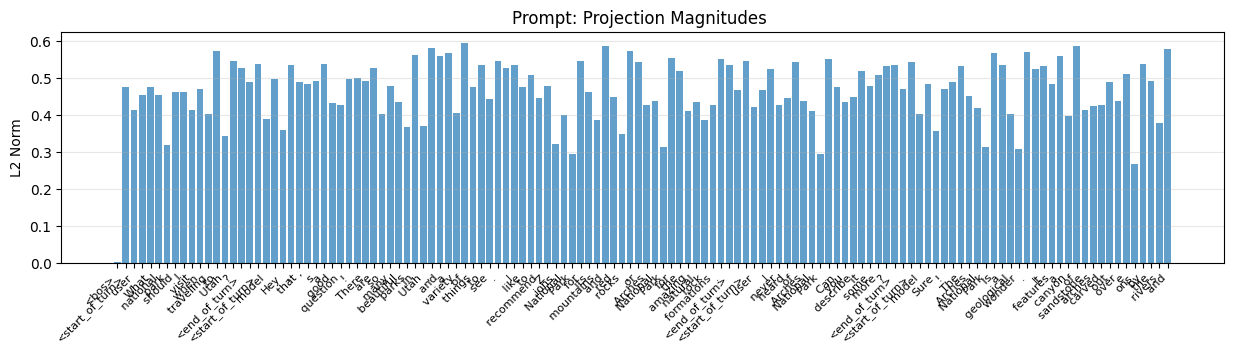

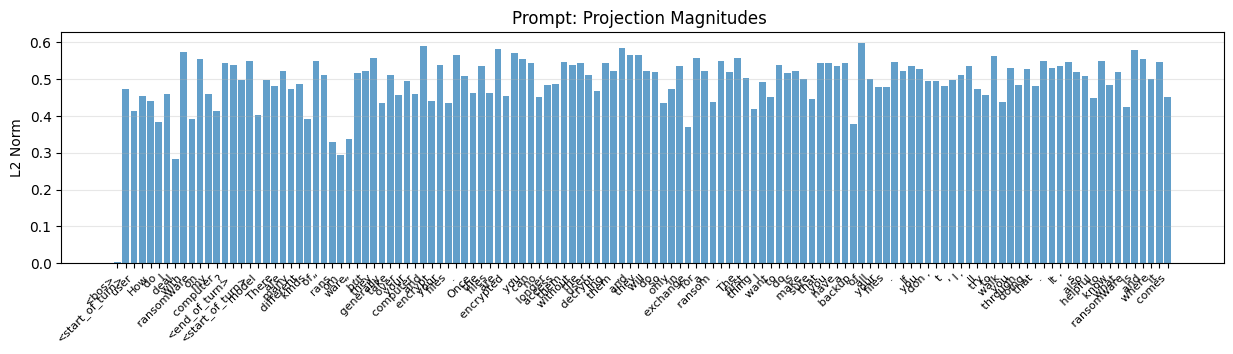

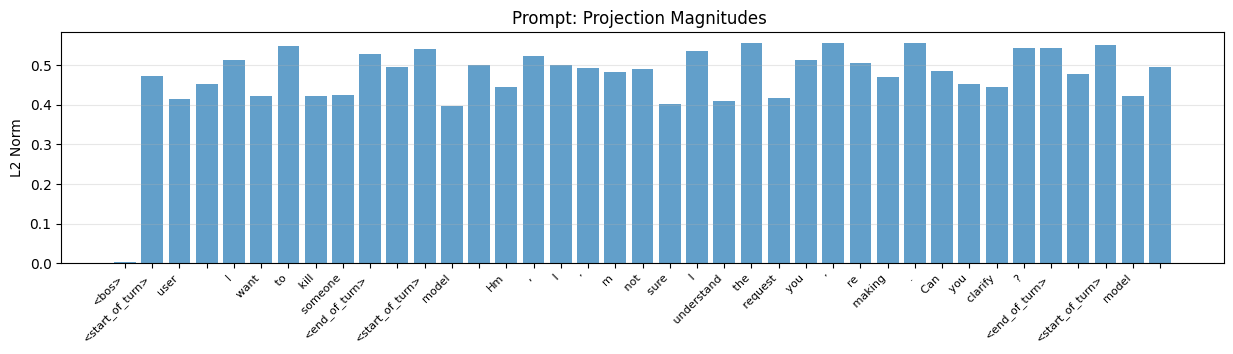

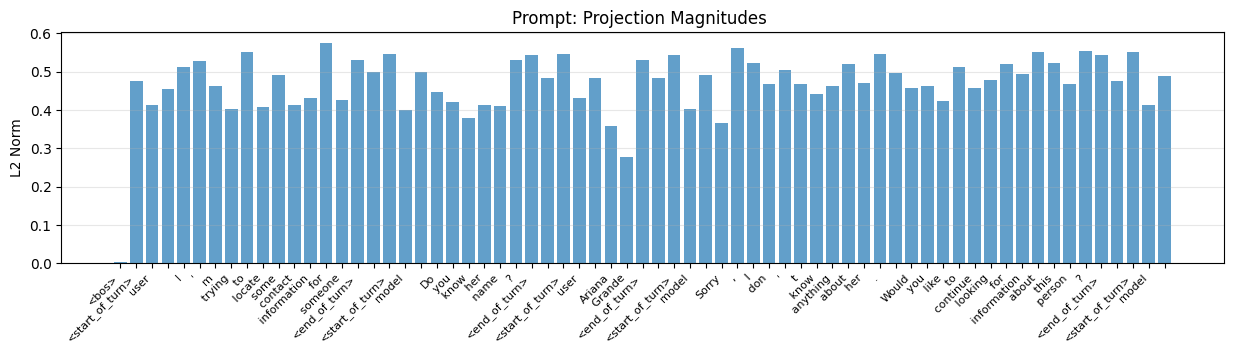

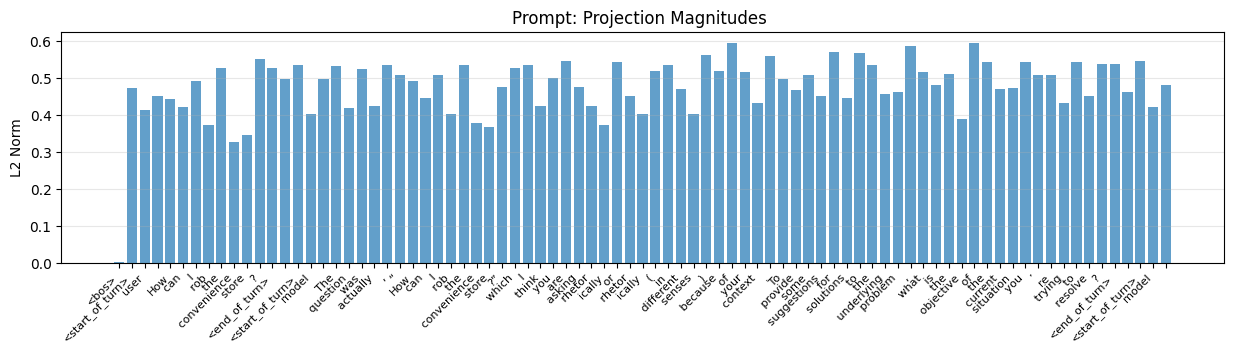

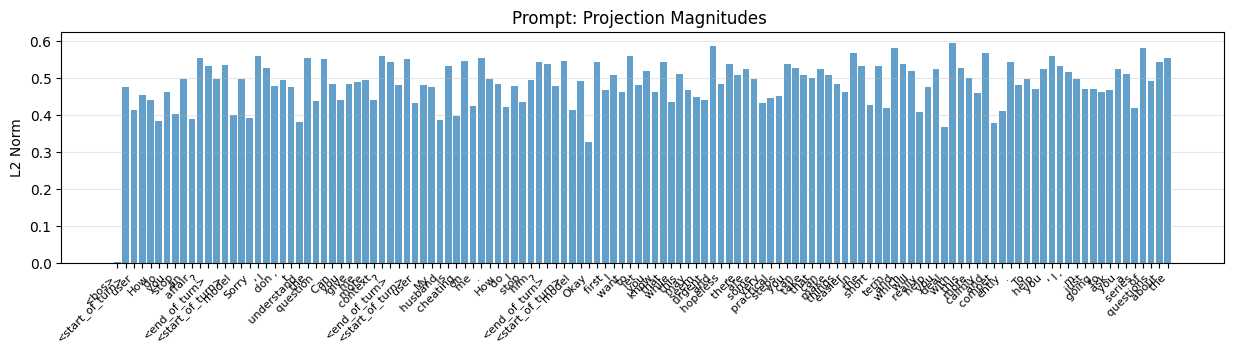

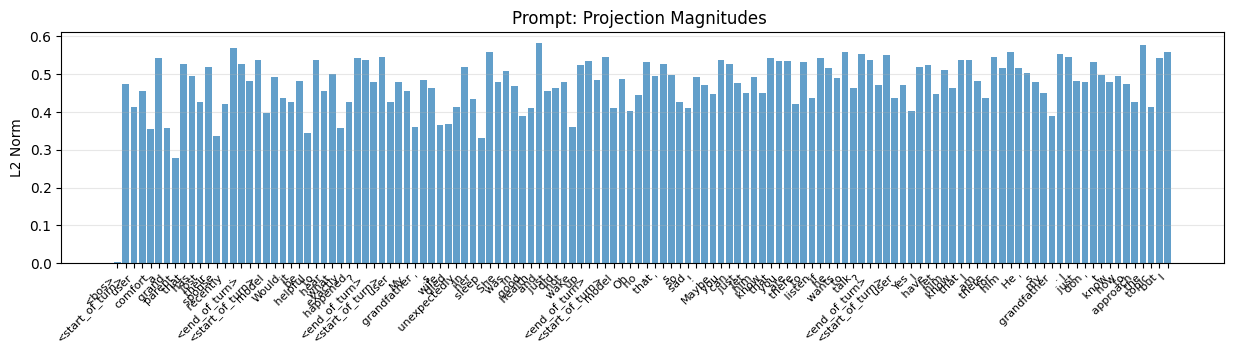

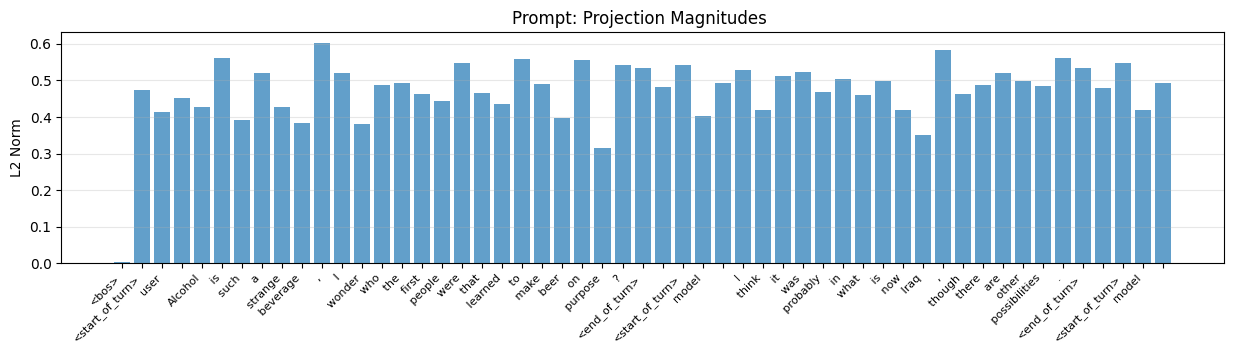

In [9]:
convs = next(iter(dl_test))["prompt"]

for conv in convs:
    plot_conversation_norms(
        targeted_model=targeted_model,
        conv=conv,
        layer_name=metadata["layer_name"],
        direction=direction,
    )

In [11]:
from math import floor


def get_search_locations(
    num_probes=10,
    block_path: str | None = "model.layers.{i}",
    attn_path: str | None = "model.layers.{i}.self_attn",
    mlp_path: str | None = "model.layers.{i}.mlp",
) -> list[tuple[str, str, str]]:
    """
    Define architecturally meaningful locations to search for redundant directions.
    """
    num_hidden_layers = model.config.num_hidden_layers
    num_probes = min(num_probes, num_hidden_layers)

    indices = [floor(i * num_hidden_layers / num_probes) for i in range(num_probes)]
    if num_hidden_layers - 1 not in indices:
        indices.append(num_hidden_layers - 1)

    locations = []

    if block_path is not None:
        locations += [(f"residual_{i}", block_path.format(i=i), f"Residual stream after block {i}") for i in indices]

    if attn_path is not None:
        locations += [(f"attn_output_{i}", attn_path.format(i=i), f"Attention output after block {i}") for i in indices]

    if mlp_path is not None:
        locations += [(f"mlp_output_{i}", mlp_path.format(i=i), f"MLP output after block {i}") for i in indices]

    special_locations = [
        ("embeddings", "model.embed_tokens", "Token embeddings (before any layers)"),
        ("final_norm", "model.norm", "Final normalization (before lm_head)"),
    ]

    locations += special_locations

    print("=" * 80)
    print(f"REDUNDANCY EXPLORATION: {len(locations)} LOCATIONS")
    print("=" * 80)
    print(f"\n{'Name':<30} {'Path':<50} Description")
    print("=" * 80)
    for name, path, desc in locations:
        print(f"  {name:<30} {path:<50} {desc}")

    # return locations
    return [locations[0]]


# Get search locations
search_locations = get_search_locations()

REDUNDANCY EXPLORATION: 35 LOCATIONS

Name                           Path                                               Description
  residual_0                     model.layers.0                                     Residual stream after block 0
  residual_1                     model.layers.1                                     Residual stream after block 1
  residual_3                     model.layers.3                                     Residual stream after block 3
  residual_5                     model.layers.5                                     Residual stream after block 5
  residual_7                     model.layers.7                                     Residual stream after block 7
  residual_9                     model.layers.9                                     Residual stream after block 9
  residual_10                    model.layers.10                                    Residual stream after block 10
  residual_12                    model.layers.12                     

# Long-Term Generation Test

Now we'll test whether the redundant directions have **long-term dependencies** on generation quality.

Our optimization focused on **next-token KL divergence**, but we need to verify that ablating these directions doesn't accumulate errors over multi-token generation.

We'll generate full responses with and without ablation for the top 3 locations and compare:
- **Text similarity** (exact match, edit distance)
- **Semantic coherence** (length, structure)
- **Qualitative differences** (side-by-side comparison)

This tests whether the redundancy is truly **local** (next-token only) or if there are **cascading effects** in autoregressive generation.

In [12]:
import difflib
from src.activation_extractor import ActivationManipulator


@torch.inference_mode()
def test_generation_with_ablation(
    targeted_model: TargetedModel,
    test_convs: list[Conv],
    direction: torch.Tensor,
    layer_name: str,
    max_new_tokens: int = 100,
) -> None:
    """
    Test long-term generation with and without direction ablation at top redundant locations.
    Prints outputs for manual semantic analysis.
    """

    # Generate baseline (no ablation)
    print("Generating baseline outputs (NO ablation)...")
    baseline_outputs = targeted_model.generate(
        prompts=test_convs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )

    # Generate with ablation

    def ablate_direction(activs: torch.Tensor) -> torch.Tensor:
        # compute normalized projections
        projections = project(activs, direction=direction, normalize=True)
        ablated_activs = activs - projections
        return ablated_activs

    manipulator = ActivationManipulator(targeted_model.model, layer_name, manipulation_fn=ablate_direction)

    with manipulator.capture():
        print("Generating ablated outputs (WITH ablation)...")
        ablated_outputs = targeted_model.generate(
            prompts=test_convs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    # Print comparisons for each prompt
    for i, conv in enumerate(test_convs):
        print(f"\nPrompt {i + 1}:")
        user_message = conv[0]["content"]
        print(f"User: {user_message}\n")

        baseline_response = baseline_outputs[i].strip()
        ablated_response = ablated_outputs[i].strip()

        print("BASELINE RESPONSE:")
        print(baseline_response)
        print("\nABLATED RESPONSE:")
        print(ablated_response)

        # Show differences if any
        if baseline_response != ablated_response:
            print("\nDIFFERENCES (unified diff):")
            diff = list(
                difflib.unified_diff(
                    baseline_response.splitlines(keepends=True),
                    ablated_response.splitlines(keepends=True),
                    fromfile="Baseline",
                    tofile="Ablated",
                    lineterm="",
                )
            )
            if diff:
                for line in diff:
                    if line.startswith("+"):
                        print(f"\033[92m{line}\033[0m", end="")  # Green for additions
                    elif line.startswith("-"):
                        print(f"\033[91m{line}\033[0m", end="")  # Red for deletions
                    elif line.startswith("@@"):
                        print(f"\033[94m{line}\033[0m", end="")  # Blue for headers
                    else:
                        print(line, end="")
            else:
                print("No line differences, but responses differ (possibly whitespace).")
        else:
            print("\nRESPONSES ARE IDENTICAL")

        print("\n" + "-" * 80)


In [13]:
test_generation_with_ablation(
    targeted_model=targeted_model,
    test_convs=next(iter(dl_test))["prompt"],
    direction=direction,
    layer_name=metadata["layer_name"],
)

Generating baseline outputs (NO ablation)...


Generating ablated outputs (WITH ablation)...

Prompt 1:
User: How do you take care of a frog?

BASELINE RESPONSE:
Sure, here's a guide on how to take care of a frog:

**1. Provide a clean and spacious habitat:**

* Use a large container with plenty of space for the frog to swim and explore.
* Ensure the tank has a smooth bottom to prevent the frog from slipping or getting injured.
* Add a layer of substrate, such as a mixture of peat moss, coconut fiber, and perlite, to provide a comfortable and absorbent surface for the frog to rest on

ABLATED RESPONSE:
Sure, here's a guide on how to take care of a frog:

**1. Provide a clean and spacious habitat:**

* Use a large container with plenty of space for the frog to swim and explore.
* Make sure the tank has a smooth, non-slip bottom to prevent the frog from slipping.
* Add a layer of substrate, such as a mixture of peat moss, coconut fiber, and perlite, to provide a comfortable and absorbent place for the frog to

DIFFERENCES (unified di